# Bridge Author Work Popularity vs. Fandom Size Analysis

This notebook explores the popularity of works written by **bridge authors** (authors who write for multiple distinct fandoms) compared to the average/median popularity within those fandoms. Specifically, we calculate the ratio of a work's popularity (e.g., Hits, Kudos, or Comments) to the average and median metrics of all works in its fandom. We then analyze whether bridge authors achieve relatively higher popularity in smaller fandoms compared to larger ones.

## 1. Setup, Imports, and Data Loading

In [1]:
%load_ext autoreload
%autoreload 2

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr

from ao3_loader import AO3DatasetLoader
from ao3_manipulator import AO3DataManipulator
from ao3_clustering import AO3FandomClustering

# Initialize loader and load the preprocessed dataframe
loader = AO3DatasetLoader()
df = loader.get_preprocessed_dataframe()

File already exists at: random works - Oct 2025.csv. Skipping download.
Loading dataset from random works - Oct 2025.csv...


Parsing list columns (Authors, Fandom Tags, Freeform Tags)...


Preprocessing complete.


## 2. Data Cleaning and Manipulation

In [2]:
# Clean and manipulate the dataset upstream using the AO3DataManipulator
manipulator = AO3DataManipulator(df)
manipulated_df = manipulator.run_all_manipulations()

print(f"Clean manipulated dataset size: {len(manipulated_df):,} rows.")

Clean manipulated dataset size: 81,326 rows.


## 3. Playable Parameter Selection

Modify the parameters in the cell below to experiment with different popularity metrics and fandom definitions.

In [3]:
# =====================================================================
# PLAYABLE PARAMETERS
# =====================================================================

# 1. Choose your popularity metric: 'Hits', 'Kudos', or 'Comments'
TARGET_METRIC = 'Hits'

# 2. Choose how you define the primary fandom tag:
#    - 'fandom_tag_1'   : The first fandom tag listed on the work.
#    - 'fandom_cluster' : Fandom tags consolidated into connected-component clusters (threshold=0.5).
#    - 'clustered_fandom': Fandom tags consolidated into high-threshold overlap clusters (threshold=0.7).
FANDOM_COLUMN = 'fandom_tag_1'

# 3. Set a minimum fandom size (number of works) to filter out tiny fandoms from the analysis
MIN_FANDOM_SIZE = 10

print(f"Selected metric: {TARGET_METRIC}")
print(f"Selected fandom column representation: {FANDOM_COLUMN}")
print(f"Selected minimum fandom size: {MIN_FANDOM_SIZE}")

Selected metric: Hits
Selected fandom column representation: fandom_tag_1
Selected minimum fandom size: 10


## 4. Compute Fandom Group Statistics

In [4]:
# Map clustered columns if requested
working_df = manipulated_df.copy()

if FANDOM_COLUMN == 'fandom_cluster':
    print("Consolidating fandom tags into connected-component clusters (threshold=0.5)...")
    clustering = AO3FandomClustering(working_df, threshold=0.5)
    working_df = clustering.get_clustered_dataframe()
elif FANDOM_COLUMN == 'clustered_fandom':
    print("Consolidating fandom tags into high-threshold overlap clusters (threshold=0.7)...")
    clustering = AO3FandomClustering(working_df, threshold=0.5)
    clustering.create_clusters()
    working_df = clustering.get_clustered_fandom_dataframe(threshold=0.7)

# Compute fandom size, mean, and median popularity
fandom_stats = working_df.groupby(FANDOM_COLUMN).agg(
    fandom_size=('Title', 'count'),
    fandom_mean_val=(TARGET_METRIC, 'mean'),
    fandom_median_val=(TARGET_METRIC, 'median')
).reset_index()

print(f"Computed statistics for {len(fandom_stats)} fandoms using metric: {TARGET_METRIC}.")
fandom_stats.head(10)

Computed statistics for 4420 fandoms using metric: Hits.


,fandom_tag_1,fandom_size,fandom_mean_val,fandom_median_val
0,#Omegaverse - Fandom,1,20.00000,20.0
1,#frouse,1,290.00000,290.0
2,#ロバ丸 #丸上,1,509.00000,509.0
3,&TEAM (Band),32,1505.71875,821.0
4,(Roblox) Dress to impress,1,232.00000,232.0
5,(여자)아이들 | (G)I-DLE,20,861.50000,540.5
6,- - Fandom,2,19.50000,19.5
7,100 Hours Hardcore SMP,1,844.00000,844.0
8,101 Dalmatian Street (Cartoon),16,2878.43750,459.0
9,13 Reasons Why (TV),1,600.00000,600.0


## 5. Identify Bridge Authors & Calculate Popularity Ratios

In [5]:
# Merge statistics back into the working dataframe
merged_df = pd.merge(working_df, fandom_stats, on=FANDOM_COLUMN, how='left')

# Ensure author is extracted as a string for grouping
merged_df['author_str'] = merged_df['parsed_authors'].apply(lambda x: x[0] if len(x) > 0 else 'Unknown')
merged_df = merged_df[merged_df['author_str'] != 'Unknown']

# Find bridge authors: authors who have written in 2 or more distinct fandom entities
author_fandom_counts = merged_df.groupby('author_str')[FANDOM_COLUMN].nunique()
bridge_authors_list = author_fandom_counts[author_fandom_counts >= 2].index.tolist()

print(f"Found {len(bridge_authors_list):,} bridge authors writing in 2 or more distinct fandom entities.")

# Filter to works written by bridge authors
bridge_works = merged_df[merged_df['author_str'].isin(bridge_authors_list)].copy()

# Calculate popularity ratio: work popularity compared to fandom average and median
bridge_works['ratio_vs_mean'] = bridge_works[TARGET_METRIC] / bridge_works['fandom_mean_val']
bridge_works['ratio_vs_median'] = bridge_works[TARGET_METRIC] / bridge_works['fandom_median_val']

# Handle division by zero or NaN values
bridge_works = bridge_works.replace([np.inf, -np.inf], np.nan).dropna(subset=['ratio_vs_mean', 'ratio_vs_median'])

# Filter out tiny fandoms based on our selection
bridge_works_filtered = bridge_works[bridge_works['fandom_size'] >= MIN_FANDOM_SIZE]

print(f"Total works by bridge authors in fandoms with size >= {MIN_FANDOM_SIZE}: {len(bridge_works_filtered):,}")

Found 4,808 bridge authors writing in 2 or more distinct fandom entities.


Total works by bridge authors in fandoms with size >= 10: 14,406


## 6. Correlation Analysis & Visualizations

We plot the bridge author's popularity ratio against the fandom size (on a log scale) and compute the Spearman rank correlation coefficient. A negative correlation indicates that bridge authors achieve relatively higher popularity (higher ratios relative to the fandom baseline) in smaller fandoms.

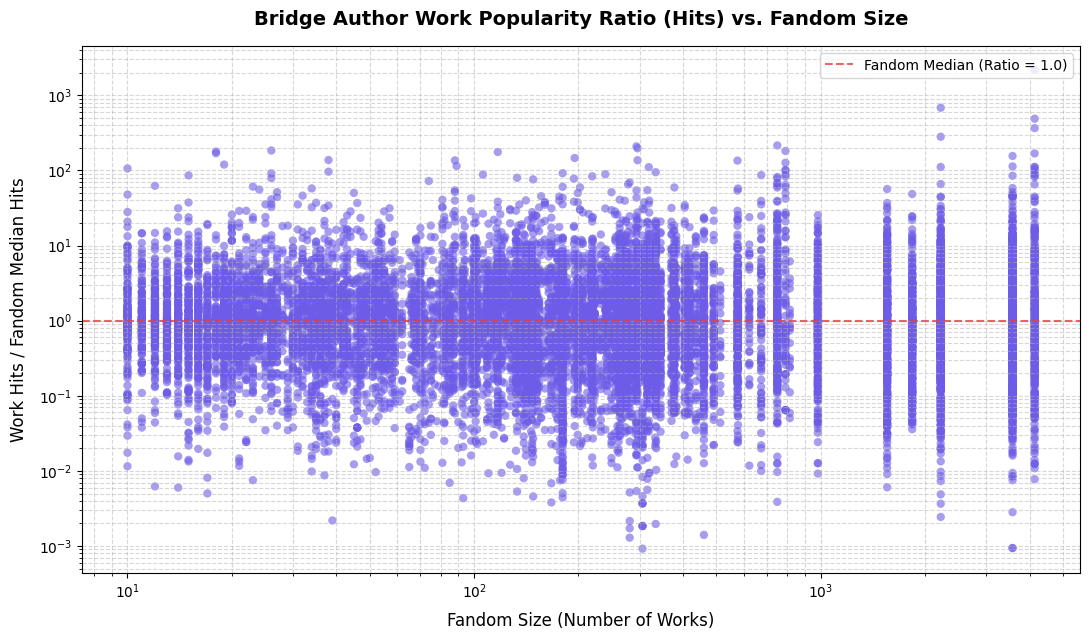

CORRELATION ANALYSIS SUMMARY (Metric: Hits, Fandom Col: fandom_tag_1)
Spearman rank correlation: -0.0192
p-value: 2.1217e-02
------------------------------------------------------------
Result: Statistically significant NEGATIVE correlation (-0.0192).
This supports the hypothesis: bridge authors achieve relatively higher popularity (Hits) in smaller fandoms.


In [6]:
# 1. Plot Popularity Ratio vs Fandom Size
plt.figure(figsize=(11, 6.5))

sns.scatterplot(
    data=bridge_works_filtered, 
    x='fandom_size', 
    y='ratio_vs_median', 
    alpha=0.6, 
    color='#6c5ce7', 
    edgecolor='none'
)

plt.xscale('log')
plt.yscale('log')

plt.axhline(1.0, color='#e53e3e', linestyle='--', linewidth=1.5, alpha=0.8, label='Fandom Median (Ratio = 1.0)')
plt.xlabel('Fandom Size (Number of Works)', fontsize=12, labelpad=8)
plt.ylabel(f'Work {TARGET_METRIC} / Fandom Median {TARGET_METRIC}', fontsize=12, labelpad=8)
plt.title(f'Bridge Author Work Popularity Ratio ({TARGET_METRIC}) vs. Fandom Size', fontsize=14, weight='bold', pad=15)
plt.legend(loc='upper right')
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.tight_layout()
plt.savefig('docs/popularity_vs_fandom_size.png', dpi=300, bbox_inches='tight')
plt.show()

# 2. Compute Spearman Rank Correlation (non-linear, robust to outliers)
corr_coeff, p_value = spearmanr(bridge_works_filtered['fandom_size'], bridge_works_filtered['ratio_vs_median'])

print("=" * 60)
print(f"CORRELATION ANALYSIS SUMMARY (Metric: {TARGET_METRIC}, Fandom Col: {FANDOM_COLUMN})")
print("=" * 60)
print(f"Spearman rank correlation: {corr_coeff:.4f}")
print(f"p-value: {p_value:.4e}")
print("-" * 60)

if corr_coeff < 0 and p_value < 0.05:
    print(f"Result: Statistically significant NEGATIVE correlation ({corr_coeff:.4f}).")
    print(f"This supports the hypothesis: bridge authors achieve relatively higher popularity ({TARGET_METRIC}) in smaller fandoms.")
elif corr_coeff < 0:
    print(f"Result: Weak negative correlation ({corr_coeff:.4f}), but not statistically significant (p = {p_value:.3f}).")
else:
    print(f"Result: No negative correlation found ({corr_coeff:.4f}).")
    print("Bridge authors do not achieve relatively higher popularity in smaller fandoms.")
print("=" * 60)

## 7. Deep Dive: Marvel (Mega-Fandom) vs. Teen Wolf (Small Fandom) Crossover

In this section, we perform a deep-dive analysis on the bridge authors who write for both the **Marvel Fandom** (a mega-fandom) and the **Teen Wolf Fandom** (a relatively small fandom).

As noted during fandom clustering, connected-component clustering at a 0.5 threshold groups `'Teen Wolf (TV)'` under the `'Marvel Cinematic Universe'` cluster due to structural crossover chaining. To ensure absolute precision and keep the two fandoms separate, we filter works using case-insensitive string matching directly on the raw `'Fandom Tags'` column.

Specifically, we:
1. Filter works matching `marvel|avengers|mcu` for Marvel, and `teen wolf` for Teen Wolf.
2. Identify the unique bridge authors writing in both groups.
3. Extract all works by these bridge authors in both fandoms into a combined, clean DataFrame (`marvel_tw_bridge_df`) and export it to a CSV file.
4. Calculate overall fandom baselines and compare them to the bridge authors' works using the active `TARGET_METRIC` (e.g., Hits, Kudos, or Comments).

Saved filtered bridge works to 'marvel_tw_bridge_works.csv'.
DEEP DIVE: MARVEL VS. TEEN WOLF (Metric: Hits)
Number of true bridge authors identified: 10
Marvel bridge works: 13 works
Teen Wolf bridge works: 11 works
Total bridge works in combined DataFrame: 24
------------------------------------------------------------
Marvel Fandom Overall Median Hits: 1102.0 (Mean: 4289.7)
Bridge Authors' Marvel Works Median Hits: 1603.0 (Mean: 4938.2)
Relative Popularity Ratio in Marvel: 1.4546
------------------------------------------------------------
Teen Wolf Fandom Overall Median Hits: 2160.0 (Mean: 5259.4)
Bridge Authors' Teen Wolf Works Median Hits: 2925.0 (Mean: 7200.9)
Relative Popularity Ratio in Teen Wolf: 1.3542

Preview of Marvel vs. Teen Wolf Bridge Works:
                                                Title  \
0                      Prince Charming and His Knight   
1                                 I’ll Watch Over You   
2   That American Dream (it'll get you every time ...   
3  

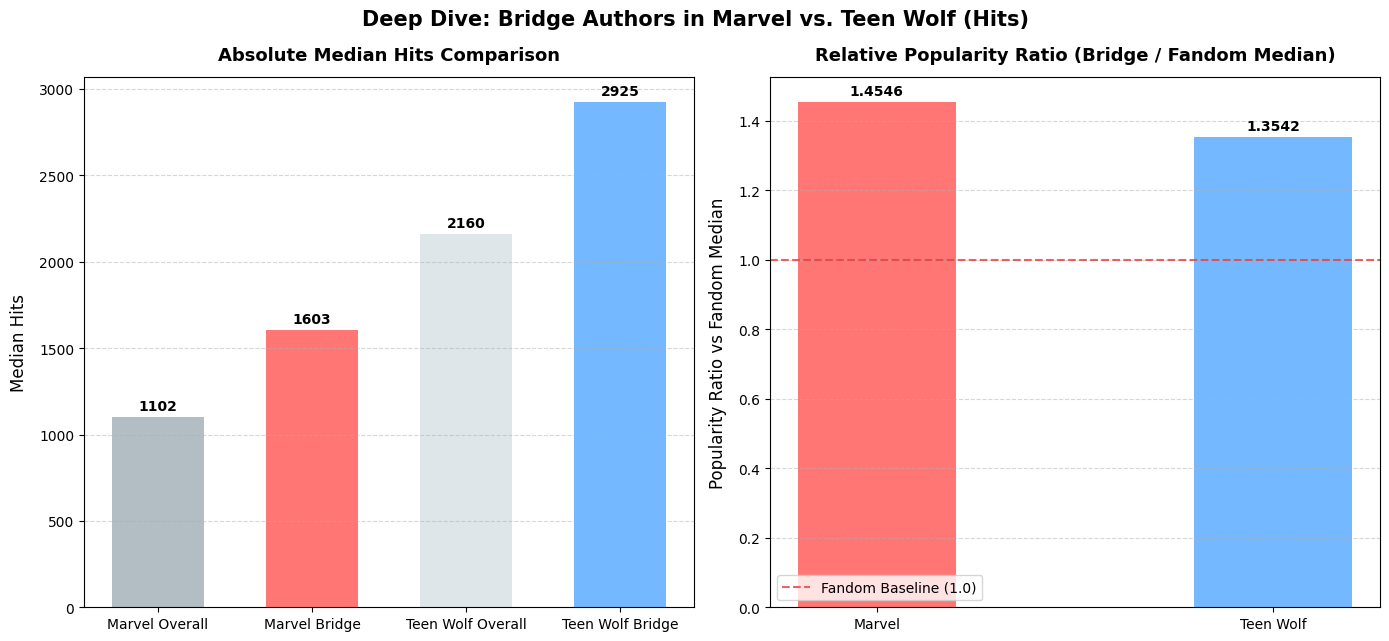

In [7]:
import re
import pandas as pd

# Ensure author_str exists in manipulated_df
if 'author_str' not in manipulated_df.columns:
    manipulated_df['author_str'] = manipulated_df['parsed_authors'].apply(lambda x: x[0] if len(x) > 0 else 'Unknown')

# 1. Define case-insensitive regex patterns for the two target fandoms
marvel_pat = re.compile(r'marvel|avengers|mcu', re.IGNORECASE)
teen_wolf_pat = re.compile(r'teen wolf', re.IGNORECASE)

# 2. Filter the manipulated DataFrame using string masks on raw 'Fandom Tags'
is_marvel = manipulated_df['Fandom Tags'].apply(lambda x: bool(marvel_pat.search(str(x))))
is_teen_wolf = manipulated_df['Fandom Tags'].apply(lambda x: bool(teen_wolf_pat.search(str(x))))

# 3. Exclude crossover works (works tagged with both Marvel AND Teen Wolf)
is_crossover = is_marvel & is_teen_wolf
marvel_only_df = manipulated_df[is_marvel & ~is_crossover].copy()
teen_wolf_only_df = manipulated_df[is_teen_wolf & ~is_crossover].copy()

# 4. Identify unique bridge authors writing in both fandoms (excluding crossovers)
marvel_only_authors = set(marvel_only_df['author_str'].unique())
teen_wolf_only_authors = set(teen_wolf_only_df['author_str'].unique())
bridge_authors = marvel_only_authors.intersection(teen_wolf_only_authors)
if 'Unknown' in bridge_authors:
    bridge_authors.remove('Unknown')

# 5. Filter works by bridge authors in both fandoms (excluding crossovers)
marvel_bridge = marvel_only_df[marvel_only_df['author_str'].isin(bridge_authors)].copy()
teen_wolf_bridge = teen_wolf_only_df[teen_wolf_only_df['author_str'].isin(bridge_authors)].copy()

# 6. Create a combined filtered DataFrame containing only the works of these bridge authors in Marvel and Teen Wolf
marvel_bridge['fandom_group'] = 'Marvel'
teen_wolf_bridge['fandom_group'] = 'Teen Wolf'
marvel_tw_bridge_df = pd.concat([marvel_bridge, teen_wolf_bridge], ignore_index=True)

# Save to CSV for easy export and further deep-dive analysis
marvel_tw_bridge_df.to_csv('marvel_tw_bridge_works.csv', index=False)
print("Saved filtered bridge works to 'marvel_tw_bridge_works.csv'.")

# 7. Calculate overall baselines for TARGET_METRIC (using all Marvel/Teen Wolf works)
marvel_overall_mean = manipulated_df[is_marvel][TARGET_METRIC].mean()
marvel_overall_median = manipulated_df[is_marvel][TARGET_METRIC].median()

tw_overall_mean = manipulated_df[is_teen_wolf][TARGET_METRIC].mean()
tw_overall_median = manipulated_df[is_teen_wolf][TARGET_METRIC].median()

# 8. Calculate bridge author work statistics for TARGET_METRIC (using non-crossover bridge works)
marvel_bridge_mean = marvel_bridge[TARGET_METRIC].mean()
marvel_bridge_median = marvel_bridge[TARGET_METRIC].median()
marvel_bridge_ratio = marvel_bridge_median / marvel_overall_median if marvel_overall_median > 0 else 0

tw_bridge_mean = teen_wolf_bridge[TARGET_METRIC].mean()
tw_bridge_median = teen_wolf_bridge[TARGET_METRIC].median()
tw_bridge_ratio = tw_bridge_median / tw_overall_median if tw_overall_median > 0 else 0

# 9. Print summary statistics
print("=" * 60)
print(f"DEEP DIVE: MARVEL VS. TEEN WOLF (Metric: {TARGET_METRIC})")
print("=" * 60)
print(f"Number of true bridge authors identified: {len(bridge_authors)}")
print(f"Marvel bridge works: {len(marvel_bridge)} works")
print(f"Teen Wolf bridge works: {len(teen_wolf_bridge)} works")
print(f"Total bridge works in combined DataFrame: {len(marvel_tw_bridge_df)}")
print("-" * 60)
print(f"Marvel Fandom Overall Median {TARGET_METRIC}: {marvel_overall_median:.1f} (Mean: {marvel_overall_mean:.1f})")
print(f"Bridge Authors' Marvel Works Median {TARGET_METRIC}: {marvel_bridge_median:.1f} (Mean: {marvel_bridge_mean:.1f})")
print(f"Relative Popularity Ratio in Marvel: {marvel_bridge_ratio:.4f}")
print("-" * 60)
print(f"Teen Wolf Fandom Overall Median {TARGET_METRIC}: {tw_overall_median:.1f} (Mean: {tw_overall_mean:.1f})")
print(f"Bridge Authors' Teen Wolf Works Median {TARGET_METRIC}: {tw_bridge_median:.1f} (Mean: {tw_bridge_mean:.1f})")
print(f"Relative Popularity Ratio in Teen Wolf: {tw_bridge_ratio:.4f}")
print("=" * 60)

# 10. Show a preview of the bridge works
print("\nPreview of Marvel vs. Teen Wolf Bridge Works:")
print(marvel_tw_bridge_df[['Title', 'author_str', 'fandom_group', TARGET_METRIC, 'Words']].head(15))

# 11. Render a premium comparison visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6.5))

# Subplot 1: Absolute Medians comparison
categories = ['Marvel Overall', "Marvel Bridge", 'Teen Wolf Overall', "Teen Wolf Bridge"]
values = [marvel_overall_median, marvel_bridge_median, tw_overall_median, tw_bridge_median]
colors = ['#b2bec3', '#ff7675', '#dfe6e9', '#74b9ff']

bars1 = ax1.bar(categories, values, color=colors, edgecolor='none', width=0.6)
ax1.set_ylabel(f'Median {TARGET_METRIC}', fontsize=12, labelpad=8)
ax1.set_title(f'Absolute Median {TARGET_METRIC} Comparison', fontsize=13, weight='bold', pad=12)
ax1.grid(True, axis='y', linestyle='--', alpha=0.5)

# Add value labels on top of the bars
for bar in bars1:
    height = bar.get_height()
    ax1.annotate(f'{height:.0f}',
                 xy=(bar.get_x() + bar.get_width() / 2, height),
                 xytext=(0, 3),  # 3 points vertical offset
                 textcoords="offset points",
                 ha='center', va='bottom', fontsize=10, weight='bold')

# Subplot 2: Relative Popularity Ratio comparison
ratios = [marvel_bridge_ratio, tw_bridge_ratio]
ratio_labels = ['Marvel', 'Teen Wolf']
ratio_colors = ['#ff7675', '#74b9ff']

bars2 = ax2.bar(ratio_labels, ratios, color=ratio_colors, edgecolor='none', width=0.4)
ax2.axhline(1.0, color='#e53e3e', linestyle='--', linewidth=1.5, alpha=0.8, label='Fandom Baseline (1.0)')
ax2.set_ylabel(f'Popularity Ratio vs Fandom Median', fontsize=12, labelpad=8)
ax2.set_title(f'Relative Popularity Ratio (Bridge / Fandom Median)', fontsize=13, weight='bold', pad=12)
ax2.grid(True, axis='y', linestyle='--', alpha=0.5)
ax2.legend(loc='lower left')

# Add ratio labels on top of the bars
for bar in bars2:
    height = bar.get_height()
    ax2.annotate(f'{height:.4f}',
                 xy=(bar.get_x() + bar.get_width() / 2, height),
                 xytext=(0, 3),  # 3 points vertical offset
                 textcoords="offset points",
                 ha='center', va='bottom', fontsize=10, weight='bold')

plt.suptitle(f'Deep Dive: Bridge Authors in Marvel vs. Teen Wolf ({TARGET_METRIC})', fontsize=15, weight='bold', y=0.98)
plt.tight_layout()
plt.savefig('docs/marvel_teen_wolf_deep_dive.png', dpi=300, bbox_inches='tight')
plt.show()